In [1]:
# import sys, kardemumma
# print(sys.executable)         # kernel Python
# print(kardemumma.__file__)    # should point to your local repo under src/kardemumma

In [2]:
# Load packages
from pathlib import Path
import os
import re
import sys
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyteomics import achrom
# Importantly, import kardemumma :)
import kardemumma as kdm

In [3]:

# Skyline data path
skyline_path = "data/2026 PD/inputs/PD_Exportfile_june30.csv"

# Import skyline data (includes column "Isotope Label Type" from Precursor)
skyline_importer = kdm.ImportSkylineFile(skyline_path)
skyline_data = skyline_importer.import_skyline_file()

Importing Skyline file: data/2026 PD/inputs/PD_Exportfile_june30.csv
File data/2026 PD/inputs/PD_Exportfile_june30.csv is valid.


In [4]:
# **SDRF**
sdrf_path = 'data/2026 PD/inputs/20260401_Parkinson_Disease.sdrf.tsv'

# Valdate sdrf fasta_file
# kdm.validate_sdrf(sdrf_path)
kdm.readout_ms_type(sdrf_path)
# Import SDRF file for this project

sdrf_data = kdm.ImportSDRFFile(sdrf_path)
sdrf_data_file = sdrf_data.import_sdrf_file()



Type(s) of MS experiment(s) in SDRF: NT=Data-Independent Acquisition;AC=NCIT:C161786
Importing SDRF file: data/2026 PD/inputs/20260401_Parkinson_Disease.sdrf.tsv


In [5]:
# # Valdate sdrf 
kdm.validate_sdrf(sdrf_path)

(True, 'Everything seems to be fine. Well done.')

In [6]:
# Print out what Peptide Sequence iRT

kdm.get_irt_peptides(skyline_data)

Checking if the peptides are from Biognosys...
Not matched: DLQAQVVESAK, ISEATDGLSDFLK, SQTPAEDTVK, ELDKYGVSDYHK, YGVSDYYK, ELDKYGVSDYYK, SIELAEAK, NLINNAK, TVEGVKDLQAQVVESAK, YGVSDYHK
Number of peptides not matching Biognosys: 10

Number of iRT peptides: 10
iRT peptides: ['ELDKYGVSDYHK', 'YGVSDYHK', 'NLINNAK', 'TVEGVKDLQAQVVESAK', 'DLQAQVVESAK', 'ISEATDGLSDFLK', 'SQTPAEDTVK', 'SIELAEAK', 'ELDKYGVSDYYK', 'YGVSDYYK']



['ELDKYGVSDYHK',
 'YGVSDYHK',
 'NLINNAK',
 'TVEGVKDLQAQVVESAK',
 'DLQAQVVESAK',
 'ISEATDGLSDFLK',
 'SQTPAEDTVK',
 'SIELAEAK',
 'ELDKYGVSDYYK',
 'YGVSDYYK']

In [7]:
# Checking possible QC samples from Skyline results

qc_samples = skyline_importer.suggest_qc_samples(skyline_data)
# skyline_checker = CheckSkylineFile(skyline_path)

# Suggest qc samples

print(qc_samples)


Number of possible QC samples: 0
Possible QC samples: []
Consider removing these QC samples before further analysis.
[]


In [10]:
# Remove QC samples from skyline_data
skyline_data = kdm.remove_qc_samples(skyline_data, qc_samples)


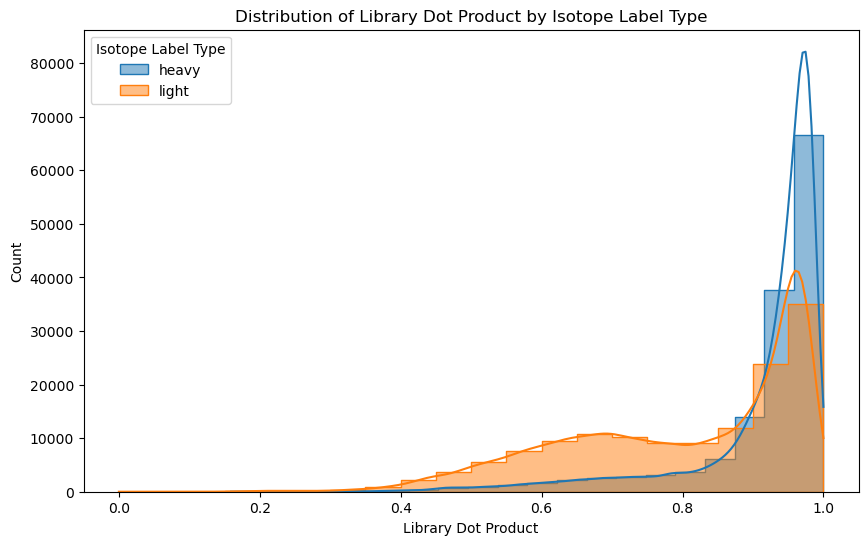

In [11]:
kdm.plot_library_dot_product_distribution(skyline_data)

In [12]:
skyline_clean = kdm.filter_library_dot_product(skyline_data, threshold=0.6)


Isotope Label Type
heavy    135589
light    119273
Name: count, dtype: int64


In [13]:
# Summarise each peptide to count how many heavy or light signals are present in skyline_pivot
peptide_counts = kdm.summarise_peptide_counts(skyline_clean)


In [14]:
report_summary, peptide_list = kdm.report_peptide_protein_summary(peptide_counts)

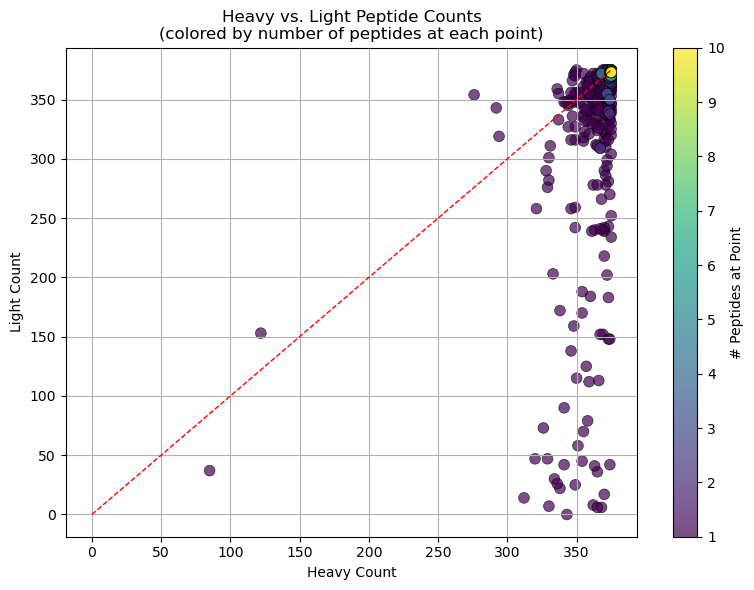

In [15]:
kdm.plot_heavy_light_scatter(peptide_counts)

In [16]:
filtered_peptide_counts = kdm.filter_peptide_counts(peptide_counts, light_cutoff=300, heavy_cutoff=300)

filtered_peptide_counts.head()


,Protein Name,Peptide,heavy_count,light_count
0,QR0140424_CKB|P12277,GTGGVDTAAVGGVFDVSNADR,374,333
1,QR0140840_SERPINA6|P08185,ITQDAQLK,344,327
2,QR0140840_SERPINA6|P08185,MNTVIAALSR,365,369
3,QR0140840_SERPINA6|P08185,WSAGLTSSQVDLYIPK,374,374
4,QR0221144_ADA2|Q9NZK5,DIPIEVCPISNQVLK,375,364


In [17]:
selected_peptides_report, selected_peptides = kdm.report_peptide_protein_summary(filtered_peptide_counts)

In [18]:
# from kardemumma.importer import MergeFiles

skyline_merge_obj = kdm.MergeFiles(skyline_data, sdrf_data_file, selected_peptides)
skyline_merge = skyline_merge_obj.merge_files()

Sample names in Skyline but not in SDRF (0).
----------------------------------------
Sample names in SDRF but not in Skyline (0).


In [19]:
skyline_merge.head(20)

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[age],characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[individual],characteristics[biological replicate],factor value[Sample]
0,488.2589++,1_A1,DIA_20260401_Parkinson_Disease_Plate_1_A1.raw,14.50,2,ISASAEELR,1.3373E+7,0.2276,0.9832,0.9919,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
1,488.2589++,1_A2,DIA_20260401_Parkinson_Disease_Plate_1_A2.raw,14.46,2,ISASAEELR,1.2769E+7,0.3743,0.9843,0.9959,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
2,488.2589++,1_A3,DIA_20260401_Parkinson_Disease_Plate_1_A3.raw,13.73,2,ISASAEELR,2.4743E+7,1.2317,0.9813,0.9792,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
3,488.2589++,1_A4,DIA_20260401_Parkinson_Disease_Plate_1_A4.raw,13.88,2,ISASAEELR,2.9822E+7,1.4326,0.9747,0.9724,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
4,488.2589++,1_A5,DIA_20260401_Parkinson_Disease_Plate_1_A5.raw,13.81,2,ISASAEELR,2.7063E+7,1.3886,0.9774,0.9803,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
5,488.2589++,1_A6,DIA_20260401_Parkinson_Disease_Plate_1_A6.raw,13.79,2,ISASAEELR,2.7385E+7,2.2268,0.9964,0.9851,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
6,488.2589++,1_A7,DIA_20260401_Parkinson_Disease_Plate_1_A7.raw,13.46,2,ISASAEELR,2.5362E+7,4.0106,0.9343,0.9654,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
7,488.2589++,1_A8,DIA_20260401_Parkinson_Disease_Plate_1_A8.raw,13.67,2,ISASAEELR,3.0558E+7,2.6424,0.9807,0.9870,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
8,488.2589++,1_A9,DIA_20260401_Parkinson_Disease_Plate_1_A9.raw,13.86,2,ISASAEELR,2.5622E+7,1.3823,0.9714,0.9791,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
9,488.2589++,1_A10,DIA_20260401_Parkinson_Disease_Plate_1_A10.raw,13.73,2,ISASAEELR,1.1540E+7,1.6630,0.9684,0.9868,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD


In [20]:
skyline_pool = skyline_merge_obj.select_pool_data(label_col='characteristics[Sample]', pool_label='Control')
# Need to check printing????

Summary of samples per plate:
Plate Plate_1: 5 unique comment[data file] names
Plate Plate_2: 5 unique comment[data file] names
Plate Plate_3: 5 unique comment[data file] names
Plate Plate_4: 5 unique comment[data file] names


In [21]:
skyline_pool.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[age],characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[individual],characteristics[biological replicate],factor value[Sample]
0,741.3798++ (heavy),1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,13.96,2,AAVYHHFISDGVR,7.3766E+6,1.2833,NaN,0.9793,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
1,736.3757++,1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,13.96,2,AAVYHHFISDGVR,7.3766E+6,1.2833,0.9619,0.9594,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
2,539.9587+++ (heavy),1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,12.85,3,AAVYHHFISDGVRK,1.1328E+7,1.2688,NaN,0.9380,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
3,533.9512+++,1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,12.85,3,AAVYHHFISDGVRK,1.1328E+7,1.2688,0.9573,0.9205,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
4,664.8145++ (heavy),1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,15.65,2,ACIPTGPYPCGK,2.1130E+6,0.9730,NaN,0.9579,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control


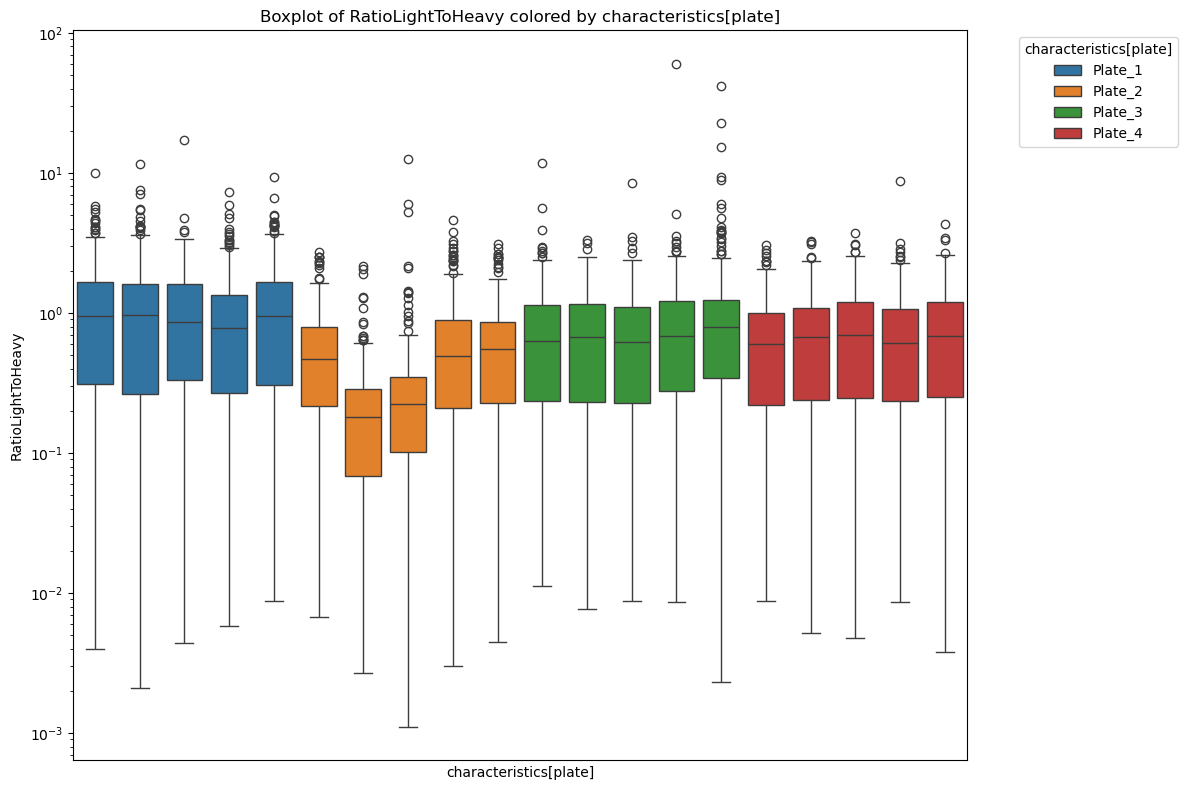

In [22]:
# Plot log_ratio of each sample in boxplot, colored by plate, but x-axis is Replicate, sorted by plate (though x labels are hidden).
kdm.plot_pool_boxplot(skyline_pool)


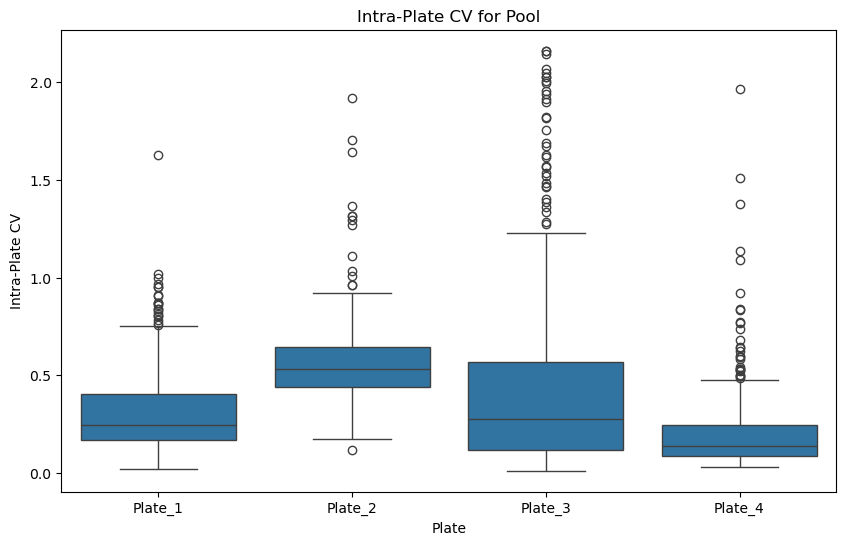

In [23]:
# Calculate intra-plate CV

peptide_plate_stats = kdm.calculate_intra_plate_cv(skyline_pool, col_name='characteristics[plate]')
kdm.plot_intra_plate_cv_stats(peptide_plate_stats, col_name='characteristics[plate]')

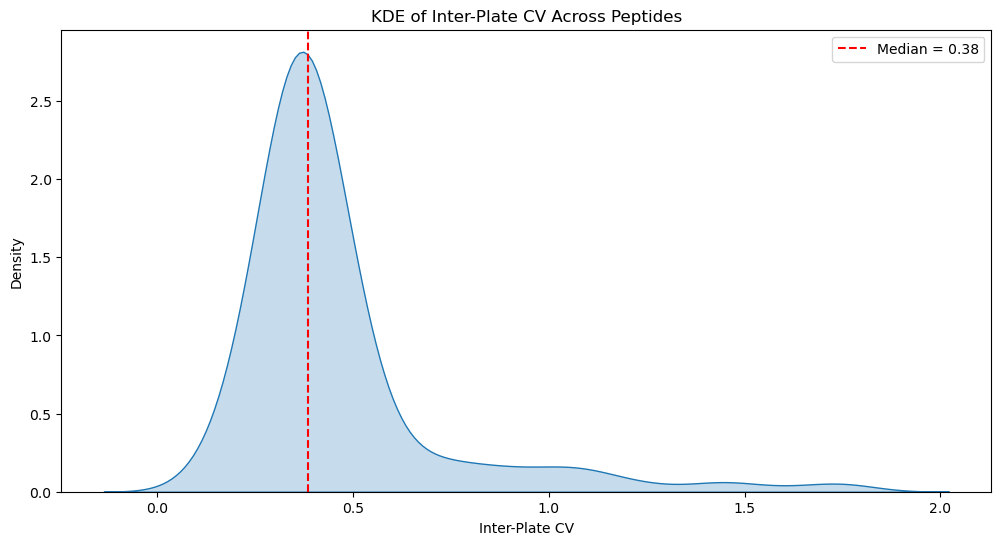

In [24]:
interplate_cv = kdm.calculate_inter_plate_cv(peptide_plate_stats)
kdm.plot_inter_plate_cv_kde(interplate_cv)

In [25]:
interplate_cv.head()

,Peptide Sequence,grand_mean,between_plate_sd,inter_plate_cv
0,FSIEGSYQLEK,0.076430,0.009254,0.121079
1,ELMGPWNKDEISTTDAIFVQR,0.226145,0.030206,0.133570
2,LYYGDDEKYFR,1.000760,0.136077,0.135974
3,TGDIVEFVCK,0.193040,0.026824,0.138953
4,QEATTVSCFR,0.491425,0.084936,0.172836


In [26]:
# Print interplate_cv froom low to high
print('This is the interplate_cv from low to high:')
print(interplate_cv[interplate_cv['inter_plate_cv'] < 0.1])

This is the interplate_cv from low to high:
Empty DataFrame
Columns: [Peptide Sequence, grand_mean, between_plate_sd, inter_plate_cv]
Index: []


Total peptides: 301
  CV < 10%: 0 peptides
  CV < 20%: 10 peptides


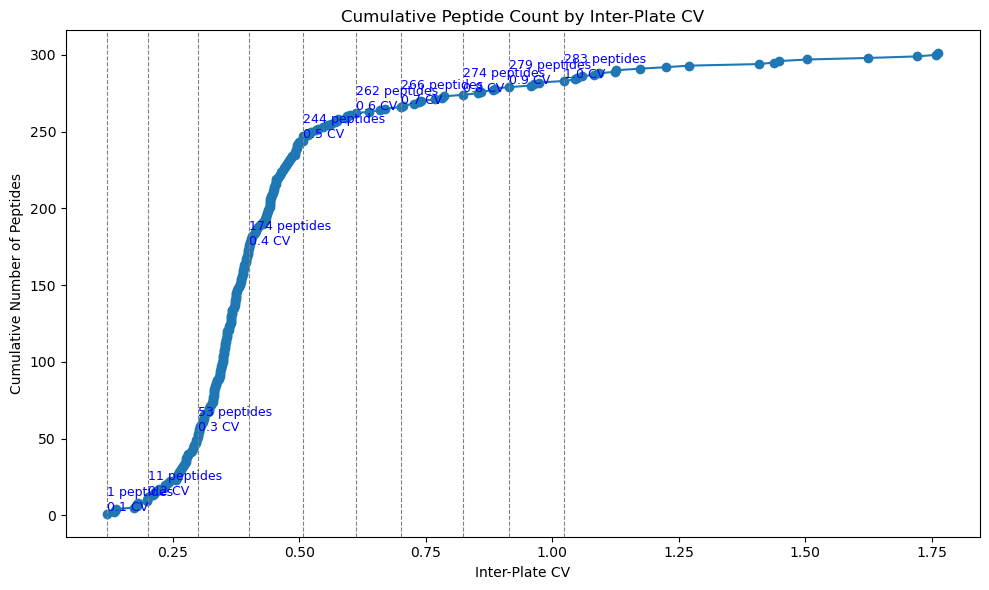

In [27]:
kdm.plot_cumulative_peptide_count_by_cv(interplate_cv)

In [28]:
selected_peptides = kdm.get_lowest_cv_peptides(interplate_cv, 20)
selected_peptides

array(['FSIEGSYQLEK', 'ELMGPWNKDEISTTDAIFVQR', 'LYYGDDEKYFR',
       'TGDIVEFVCK', 'QEATTVSCFR', 'GILAADESTGSIAK', 'KWIYHLTEGSTDLR',
       'FCPDGSPSECHEHADCVLER', 'AKLEEQAQQIR', 'WYEIEKIPTTFENGR'],
      dtype=object)

In [29]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) 
# using only peptides in the top 10% lowest inter-plate CV for normalization

pool_selected_df = skyline_pool[skyline_pool['Peptide Sequence'].isin(selected_peptides)]

# Remove bad plasmapool 

bad_pools = [
       'PRM_20260422_DA_4K_B2_Plate_7_C1.raw',
       'PRM_20260422_DA_4K_B2_Plate_8_B8.raw']


# Remove bad peptides 
bad_peptides = ['ESDTSYVSLK', 'VTLNGVPAQPLGPR', 'FSIEGSYQLEK', 'GLLSGWAR']

# Filter bad_pools from pool_selected_df
pool_selected_df = pool_selected_df[~pool_selected_df['File Name'].isin(bad_pools)]

# Filter bad_peptides from pool_selected_df
pool_selected_df = pool_selected_df[~pool_selected_df['Peptide Sequence'].isin(bad_peptides)]

# Filter pool_data to include only those peptides for normalization calculation
pool_selected_df

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[age],characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[individual],characteristics[biological replicate],factor value[Sample]
26,666.3735++ (heavy),1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,12.65,2,AKLEEQAQQIR,1.8538E+7,2.5249,NaN,0.9835,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
27,657.3622++,1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,12.65,2,AKLEEQAQQIR,1.8538E+7,2.5249,0.9793,0.9773,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
100,823.4130+++ (heavy),1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,23.58,3,ELMGPWNKDEISTTDAIFVQR,2.3155E+5,0.3108,NaN,0.9519,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
101,817.4055+++,1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,23.58,3,ELMGPWNKDEISTTDAIFVQR,2.3155E+5,0.3108,0.8443,0.8502,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
120,804.6608+++ (heavy),1_B6,DIA_20260401_Parkinson_Disease_Plate_1_B6.raw,14.06,3,FCPDGSPSECHEHADCVLER,1.4651E+5,0.0984,NaN,0.9816,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11815,599.7797++,4_G6,DIA_20260401_Parkinson_Disease_Plate_4_G6.raw,14.47,2,QEATTVSCFR,3.4341E+5,0.4281,0.9540,0.9581,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
11900,588.2965++ (heavy),4_G6,DIA_20260401_Parkinson_Disease_Plate_4_G6.raw,19.90,2,TGDIVEFVCK,9.8485E+5,0.1666,NaN,0.9270,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
11901,584.2894++,4_G6,DIA_20260401_Parkinson_Disease_Plate_4_G6.raw,19.90,2,TGDIVEFVCK,9.8485E+5,0.1666,0.9309,0.9016,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
12016,950.9816++ (heavy),4_G6,DIA_20260401_Parkinson_Disease_Plate_4_G6.raw,21.59,2,WYEIEKIPTTFENGR,3.2631E+5,0.7424,NaN,0.8999,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control


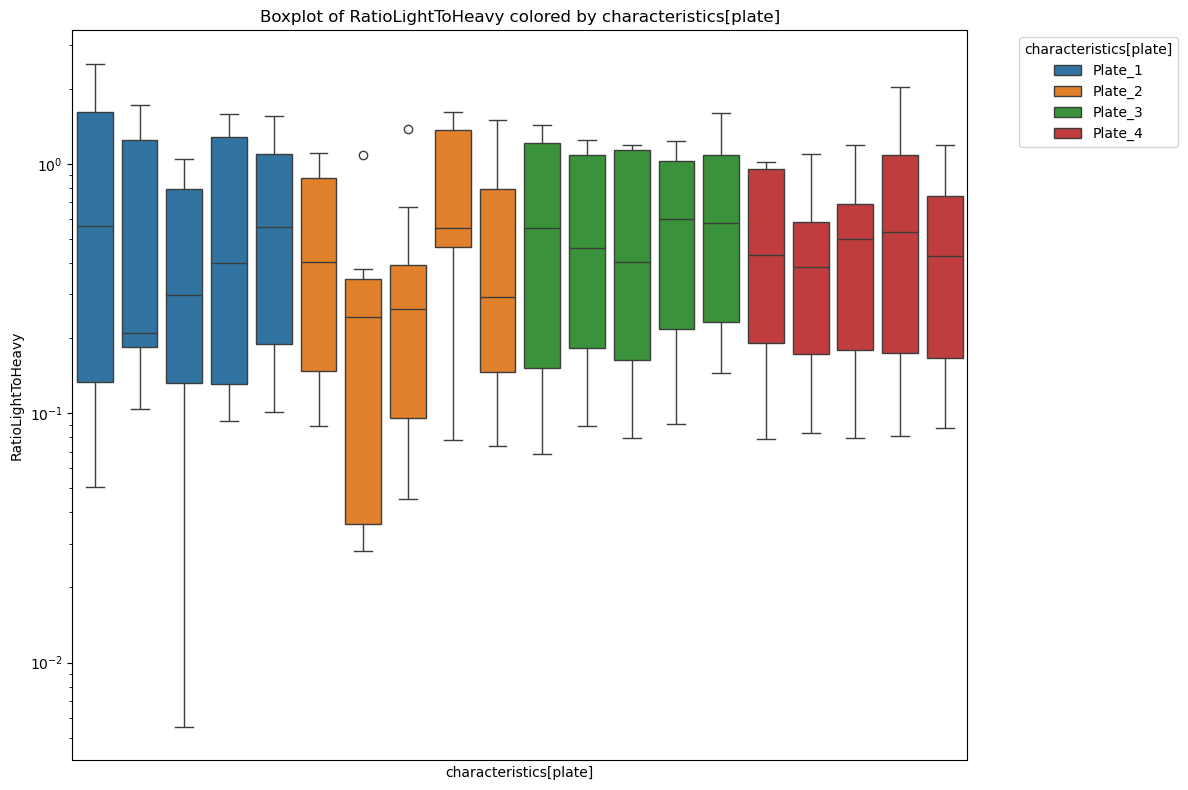

In [30]:
kdm.plot_pool_boxplot(pool_selected_df)

In [31]:
plate_factor_table, conversion_factors, model = kdm.get_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=True  )

Conversion factors: {'Plate_1': 0.995788186815769, 'Plate_2': 0.8001062539832557, 'Plate_3': 1.4571051959429178, 'Plate_4': 1.087966301837379}


In [32]:
plate_factor_table

,characteristics[plate],plate_median,correction_factor
0,Plate_1,-0.918543,0.995788
1,Plate_2,-1.143191,0.800106
2,Plate_3,-0.627734,1.457105
3,Plate_4,-0.840720,1.087966


In [33]:
conversion_factors

{'Plate_1': 0.995788186815769,
 'Plate_2': 0.8001062539832557,
 'Plate_3': 1.4571051959429178,
 'Plate_4': 1.087966301837379}

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:694: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


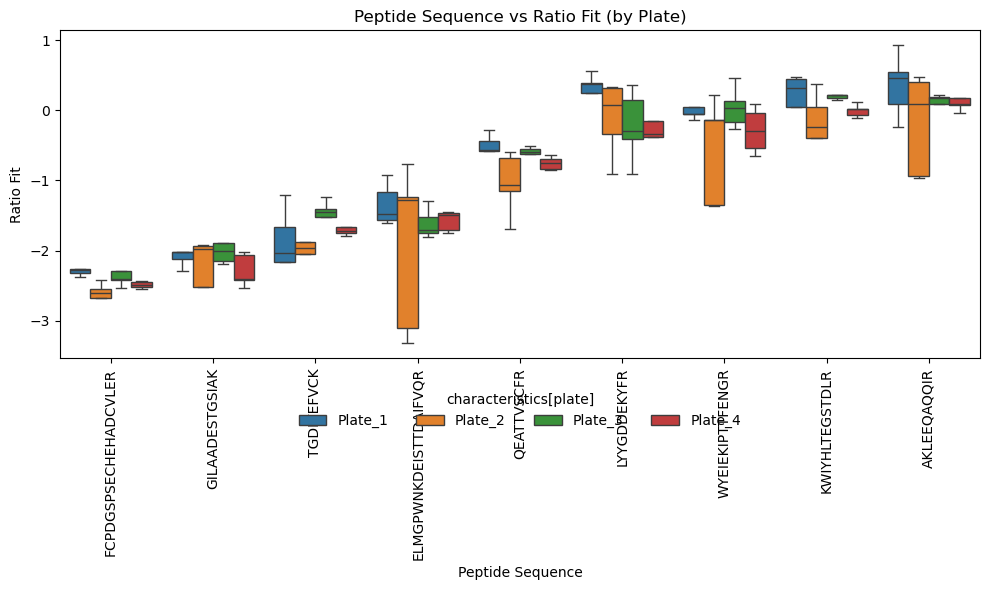

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [34]:
kdm.plot_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=True  )

In [35]:
# Use the adjust_ratio_by_plate function above to add RatioLightToHeavy_adj to skyline_merge
# First, construct a Plate column of the correct type for the function
skyline_merge_adj = skyline_merge.copy()
# Remove samples from Replicate column that are in qc_samples
skyline_merge_adj = skyline_merge_adj[~skyline_merge_adj['Replicate'].isin(qc_samples)]

# Remove sampels from Plate_1 from characteristics[plate]
skyline_merge_adj = skyline_merge_adj[skyline_merge_adj['characteristics[plate]'] != 'Plate_1']


In [36]:
# Adjust ratio by conversion factor 
skyline_merge_adj = kdm.adjust_ratio_by_plate(skyline_merge_adj, conversion_factors)

skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[age],characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[individual],characteristics[biological replicate],factor value[Sample]
96,488.2589++,2_A1,DIA_20260401_Parkinson_Disease_Plate_2_A1.raw,13.89,2,ISASAEELR,3.8480E+7,1.516924,0.9873,0.9908,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
97,488.2589++,2_A2,DIA_20260401_Parkinson_Disease_Plate_2_A2.raw,13.93,2,ISASAEELR,3.0056E+7,1.271456,0.9900,0.9875,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
98,488.2589++,2_A3,DIA_20260401_Parkinson_Disease_Plate_2_A3.raw,13.97,2,ISASAEELR,1.4325E+7,0.749775,0.9764,0.9876,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
99,488.2589++,2_A4,DIA_20260401_Parkinson_Disease_Plate_2_A4.raw,13.97,2,ISASAEELR,2.7773E+7,1.722021,0.9737,0.9787,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
100,488.2589++,2_A5,DIA_20260401_Parkinson_Disease_Plate_2_A5.raw,13.99,2,ISASAEELR,2.4697E+7,1.198841,0.9873,0.9870,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD


In [37]:
# From skyline_merge_adj, filter to pool samples
pool_data_adj = skyline_merge_adj[skyline_merge_adj['characteristics[Sample]'] != 'PlasmaPool'].copy()

# Reorder by characteristics[Plate]
pool_data_adj = pool_data_adj.sort_values(by='characteristics[plate]')

pool_data_adj.head()


,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[age],characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[individual],characteristics[biological replicate],factor value[Sample]
96,488.2589++,2_A1,DIA_20260401_Parkinson_Disease_Plate_2_A1.raw,13.89,2,ISASAEELR,3.8480E+7,1.516924,0.9873,0.9908,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
158039,1003.4692++ (heavy),2_F9,DIA_20260401_Parkinson_Disease_Plate_2_F9.raw,16.42,2,TTLSGAPCQPWASEATYR,1.8366E+4,1.047611,NaN,0.6592,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
158040,1003.4692++ (heavy),2_F10,DIA_20260401_Parkinson_Disease_Plate_2_F10.raw,19.31,2,TTLSGAPCQPWASEATYR,1.2429E+6,0.505058,NaN,0.9515,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
158041,1003.4692++ (heavy),2_F11,DIA_20260401_Parkinson_Disease_Plate_2_F11.raw,19.03,2,TTLSGAPCQPWASEATYR,2.1192E+6,0.615793,NaN,0.9609,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
158042,1003.4692++ (heavy),2_F12,DIA_20260401_Parkinson_Disease_Plate_2_F12.raw,19.62,2,TTLSGAPCQPWASEATYR,1.2973E+6,0.561550,NaN,0.9707,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD


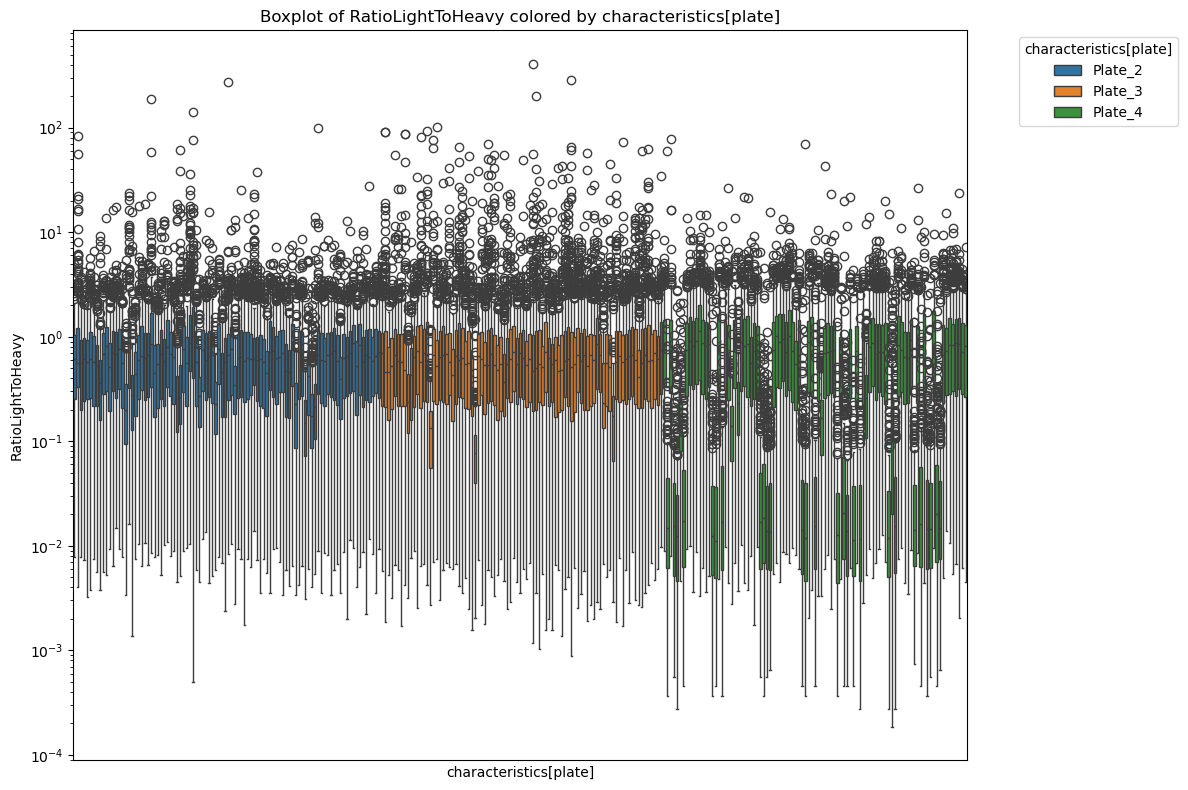

In [38]:
kdm.plot_pool_boxplot(pool_data_adj)

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:694: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


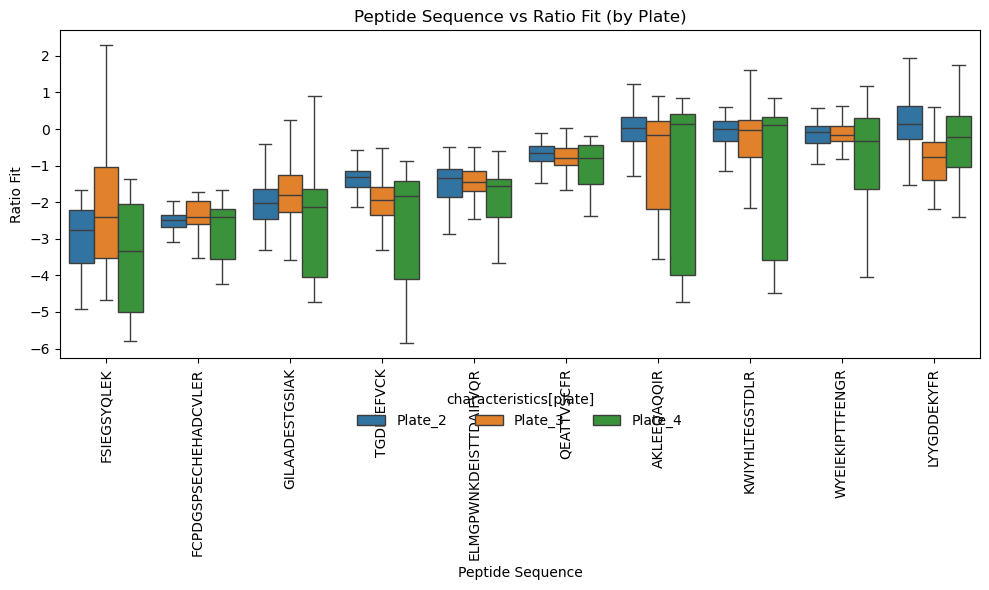

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [39]:
pool_selected_adj = pool_data_adj[pool_data_adj['Peptide Sequence'].isin(selected_peptides)]

kdm.plot_plate_conversion_factors(pool_selected_adj, col_plate='characteristics[plate]', log_transform=True  )

# SDRF metadata

Overview of metadata

# Calculate absolute quantification

In [41]:
qreps_lot = sdrf_data.extract_qreps_lot_number()
print(qreps_lot)

qREPs lot number: 24005
24005


In [42]:
# Extract qRePS lot from SDRF file 
qreps_lot = sdrf_data.extract_qreps_lot_number()
# Fetch qRePS table
qreps_table = kdm.fetch_qreps_table(qreps_lot)

qreps_table.head()


qREPs lot number: 24005


,qRePS,Gene,Protein,Uniprot,Amount per well [pmol]
0,QR3140513,A1BG,Alpha-1B-glycoprotein,P04217,1.309
1,QR5000096,A2M,Alpha-2-macroglobulin,P01023,3.604
2,QR0140749,ACTN1,Alpha-actinin-1,P12814,0.157
3,QR0221144,ADA2,Adenosine deaminase 2,Q9NZK5,0.015
4,QR5000237,ADAMTS13,A disintegrin and metalloproteinase with throm...,Q76LX8,0.057


In [43]:
skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[age],characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[individual],characteristics[biological replicate],factor value[Sample]
96,488.2589++,2_A1,DIA_20260401_Parkinson_Disease_Plate_2_A1.raw,13.89,2,ISASAEELR,3.8480E+7,1.516924,0.9873,0.9908,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
97,488.2589++,2_A2,DIA_20260401_Parkinson_Disease_Plate_2_A2.raw,13.93,2,ISASAEELR,3.0056E+7,1.271456,0.9900,0.9875,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
98,488.2589++,2_A3,DIA_20260401_Parkinson_Disease_Plate_2_A3.raw,13.97,2,ISASAEELR,1.4325E+7,0.749775,0.9764,0.9876,...,not available,not available,not available,not available,not available,not available,not available,not available,1,Control
99,488.2589++,2_A4,DIA_20260401_Parkinson_Disease_Plate_2_A4.raw,13.97,2,ISASAEELR,2.7773E+7,1.722021,0.9737,0.9787,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD
100,488.2589++,2_A5,DIA_20260401_Parkinson_Disease_Plate_2_A5.raw,13.99,2,ISASAEELR,2.4697E+7,1.198841,0.9873,0.9870,...,not available,not available,not available,not available,not available,not available,not available,not available,1,PD


In [44]:
# Calculate absolute protein concentration
abs_df = kdm.get_absolute_conc(qreps_table, skyline_merge_adj)

Number of out of bounds ratios: 474
Ratio cutoff low: 0.001
Ratio cutoff high: 1000
Number of unique qRePS ids: 149
Number of unique Peptide Sequences: 301
Number of unique Protein Names: 149
Number of unique File Names: 279


In [45]:
target_fasta = 'https://proteomedge.com/download/DE17501/DE17501_sequences.fasta'

# Read fasta file
fasta_file = kdm.fetch_fasta(qreps_lot)
fasta_file.head()

,id,sequence
0,QR0520106_CSF1R|P07333,TYRHTFTLSLPRLKPSEAGRYSFLARNPGGWRALTFELTLRYPPEV...
1,QR0280166_C1R|P00736,PNNFETTTVITVPTGYRVKLVFQQFDLEPSEGCFYDYVKISADKKS...
2,QR7000010_PROCR|Q9UNN8,RTLAFPLTIRCFLGCELPPEGSRAHVFFEVAVNGSSFVSFRPERAL...
3,QR4160204_F7|P08709,EHDGDEQSRRVAQVIIPSTYVPGTTNHDIALLRLHQPVVLTDHVVP...
4,QR0221144_ADA2|Q9NZK5,TDWQGTSIDRNILDALMLNTTRIGHGFALSKHPAVRTYSWKKDIPI...


(<Figure size 2800x800 with 5 Axes>, <Figure size 1800x110 with 1 Axes>)

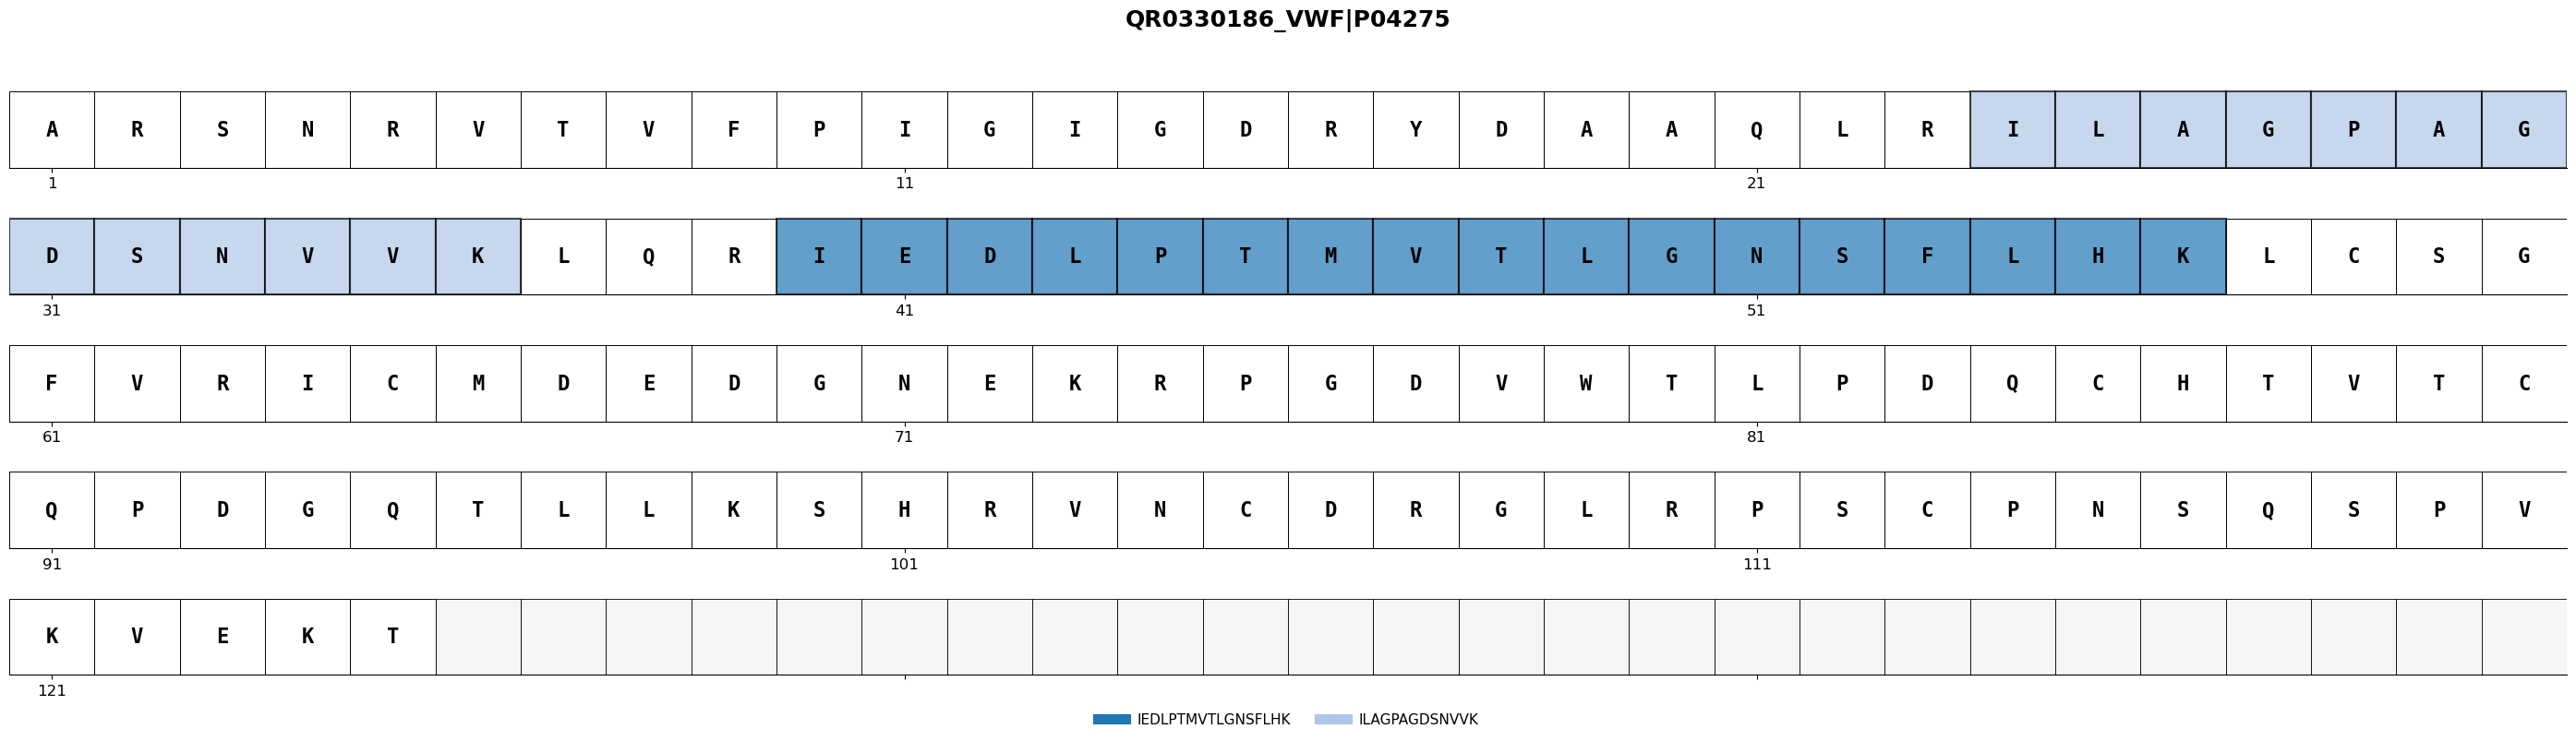

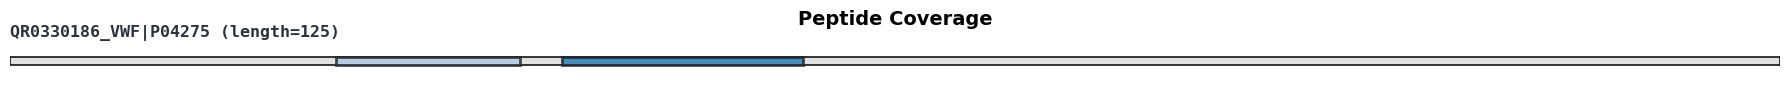

In [46]:
kdm.map_peptide_sequence(abs_df, fasta_file, 'QR0330186_VWF|P04275')

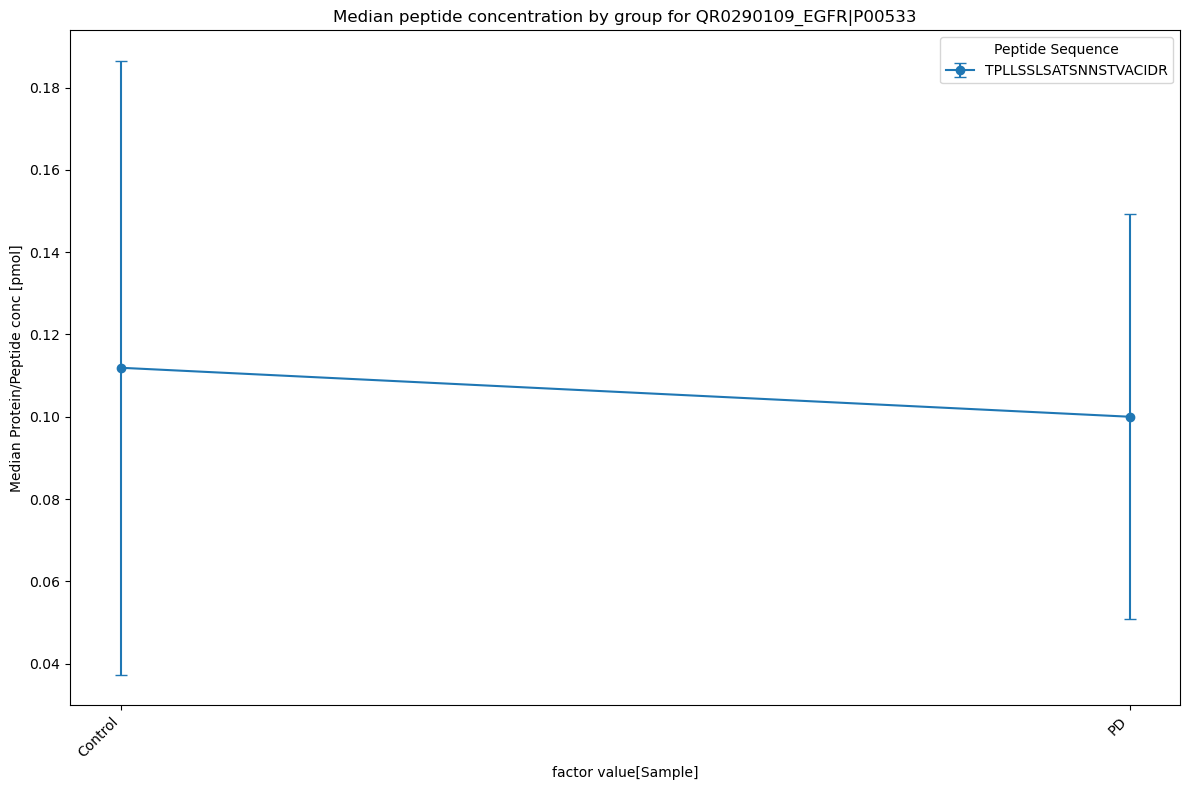

In [47]:
kdm.plot_median_peptide_concentration_by_group(
    abs_df,
    sdrf_data_file,
    protein_name="QR0290109_EGFR|P00533",
)

In [48]:
# kdm.plot_all_median_peptide_concentration_by_group(
#     abs_df,
#     sdrf_data_file,
#     pdf_path="data/DA4000/median_peptide_concentration_by_group.pdf",
# )

In [50]:
sdrf_data_file.head()

,source name,characteristics[Row],characteristics[Column],characteristics[Sample],characteristics[organism],characteristics[organism part],characteristics[plate],characteristics[project],characteristics[age],characteristics[developmental stage],...,comment[instrument],comment[modification parameters],comment[dissociation method],comment[collision energy],comment[precursor mass tolerance],comment[fragment mass tolerance],comment[MS1 scan range],comment[MS2 scan range],comment[ProteomEdge],factor value[Sample]
0,DIA_20260401_Parkinson_Disease_Plate_1_A1,A,1,PD,Homo sapiens,blood plasma,Plate_1,Parkinson_Disease,not available,not available,...,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,400-1250 m/z,100-2000 m/z,24005,PD
1,DIA_20260401_Parkinson_Disease_Plate_1_A2,A,2,PD,Homo sapiens,blood plasma,Plate_1,Parkinson_Disease,not available,not available,...,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,400-1250 m/z,100-2000 m/z,24005,PD
2,DIA_20260401_Parkinson_Disease_Plate_1_A3,A,3,PD,Homo sapiens,blood plasma,Plate_1,Parkinson_Disease,not available,not available,...,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,400-1250 m/z,100-2000 m/z,24005,PD
3,DIA_20260401_Parkinson_Disease_Plate_1_A4,A,4,PD,Homo sapiens,blood plasma,Plate_1,Parkinson_Disease,not available,not available,...,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,400-1250 m/z,100-2000 m/z,24005,PD
4,DIA_20260401_Parkinson_Disease_Plate_1_A5,A,5,PD,Homo sapiens,blood plasma,Plate_1,Parkinson_Disease,not available,not available,...,NT=Stellar;AC=MS:1003409,NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed,NT=Higher-energy Collisional Dissociation;AC=M...,27 NCE,40 ppm,0.05 Da,400-1250 m/z,100-2000 m/z,24005,PD


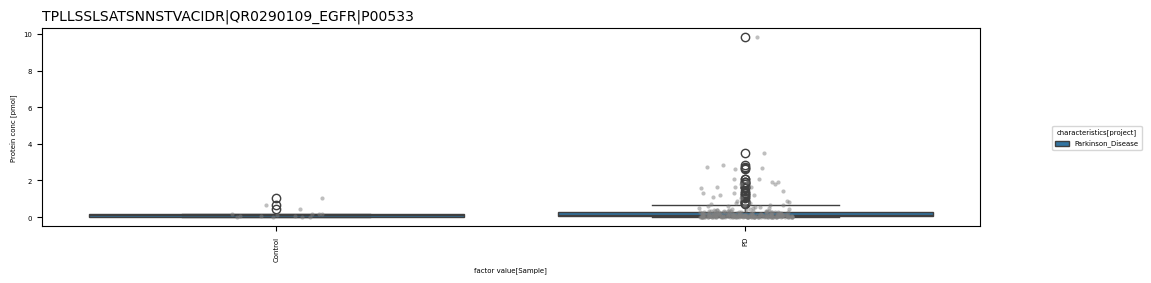

In [52]:
kdm.plot_peptide_concentration_by_group(
    abs_df,
    sdrf_data_file,
    color_col='characteristics[project]',
    protein_name="QR0290109_EGFR|P00533",
)

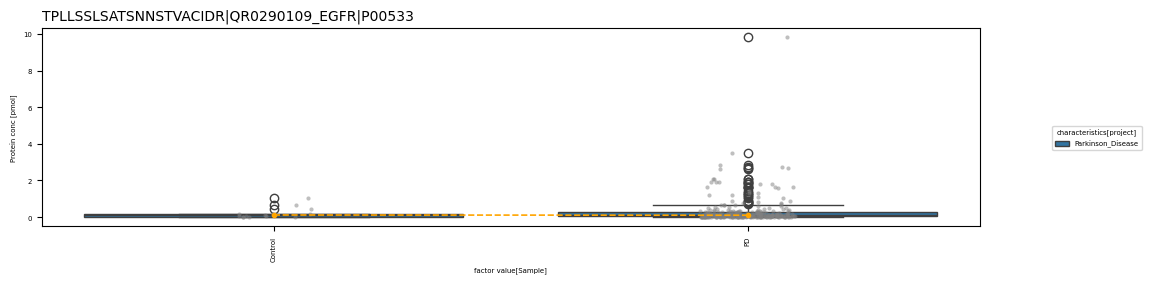

In [54]:
kdm.plot_peptide_all(
    abs_df,
    sdrf_data_file,
    color_col='characteristics[project]',
    protein_name="QR0290109_EGFR|P00533",
)

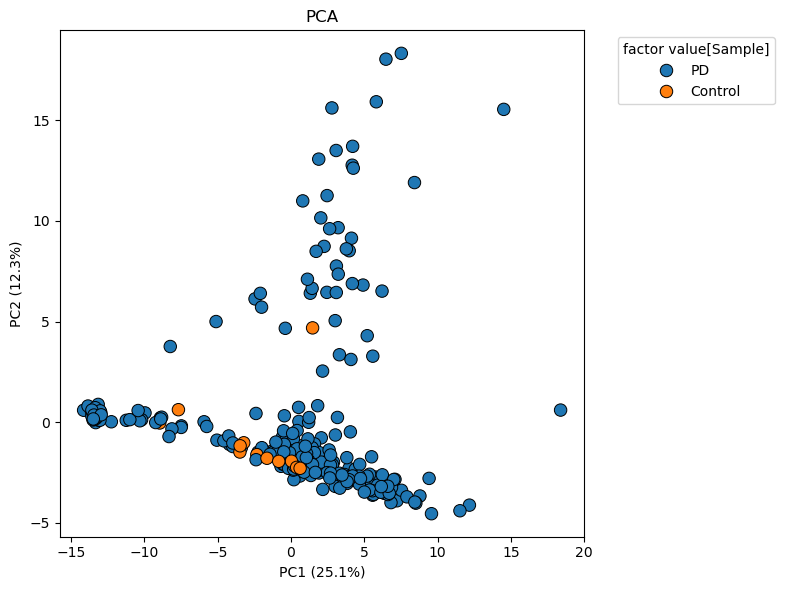

In [55]:
kdm.plot_pca(
    abs_df,
    sdrf_data_file
    
)

/home/thanadol/Documents/GitHub/kardemumma/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/thanadol/Documents/GitHub/kardemumma/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


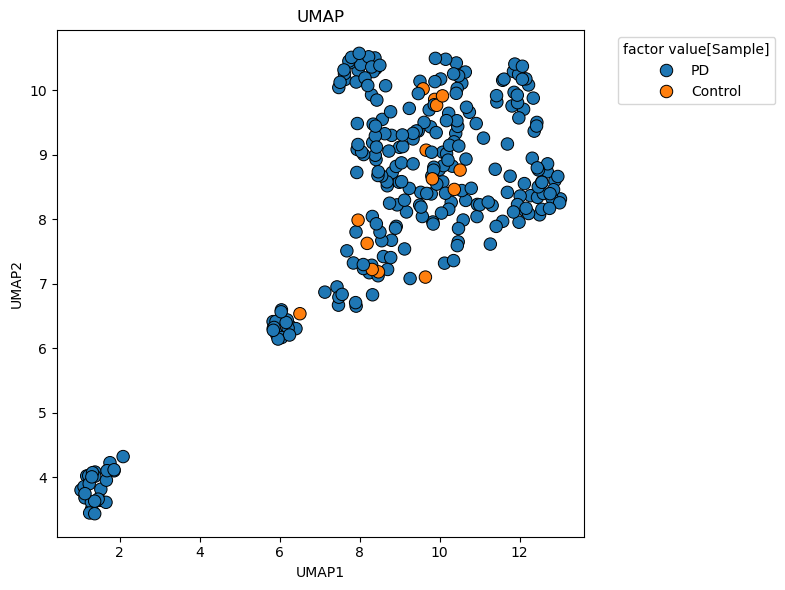

In [56]:
kdm.plot_umap(
    abs_df,
    sdrf_data_file
)
